Within the case of consignment types within countries in the European Union for rail freight, there are primarily 2 types of identifiable data present on Eurostat. They are:

**Full Train Load:**
This consignment type comprises a single type of goods being transported by a single train, within a single integrated consignment note and wagon lists.

**Full Wagon Load:**
This consignment type comprises multiple types of goods being transported within a single train, with various consignment notes and wagon lists.

The countries being considered here are given in the following table along with their country codes for easier identification.



| Country     | Code |
|--------------|------|
| Switzerland  | CH   |
| Germany      | DE   |
| Italy        | IT   |
| Poland       | PL   |
| Sweden       | SE   |
| Slovenia     | SI   |
| Slovakia     | SK   |


These countries have been chosen for the analysis as the data for these were available to a larger extent as compared to other countries from the European Union. Few countries had some data missing for some years and hence its data has been interpolated and extrapolated in those cases.\
\
Considering the case of full train loads, the following plot has been obtained for the following.


In [18]:
# Import necessary packages
import pandas as pd
import plotly.express as px


In [19]:
# --- Read the CSV file ---
df = pd.read_csv('df_merged_filled.csv')

# --- Select and rename relevant columns ---
df_plot = df[['geo', 'TIME_PERIOD',
              'Consignment_full_train_load_THS_T',
              'Consignment_full_wagon_load_THS_T',
              'Consignment_total_THS_T']].copy()

df_plot.columns = ['Country', 'Year', 'Full_Train', 'Full_Wagon', 'Total']
df_plot['Year'] = df_plot['Year'].astype(int)

# --- Country name mapping ---
country_names = {
    'CH': 'Switzerland',
    'DE': 'Germany',
    'IT': 'Italy',
    'PL': 'Poland',
    'SE': 'Sweden',
    'SI': 'Slovenia',
    'SK': 'Slovakia'
}
df_plot['Country_Name'] = df_plot['Country'].map(country_names)

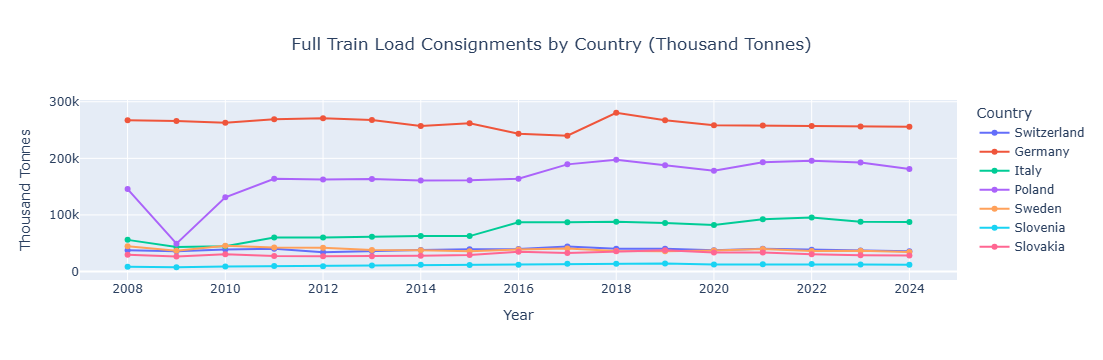

In [20]:
# --- Plot 1: Full Train Load ---
fig1 = px.line(
    df_plot,
    x='Year',
    y='Full_Train',
    color='Country_Name',
    markers=True,
    title='Full Train Load Consignments by Country (Thousand Tonnes)',
    labels={'Full_Train': 'Thousand Tonnes', 'Country_Name': 'Country'}
)
fig1.update_layout(title_x=0.5, legend_title_text='Country', hovermode='x unified')
fig1.show()

The output here describes the full train load that is carried in rail freight to the countries mentioned above. Here it is seen that Germany carries the largest quantity (Thousand Tonnes) of full train load consignment type while Slovenia has the least amount of full train loads being carried.Italy has shown a relatively steady increase in the amount of full load trains. Switzerland, Slovakia and Sweden have shown a steady trend of full train loads, with Slovakia showing signs of decline. Poland has witnessed a drastic drop from 2008 till 2009 but then gained it as quickly, showing resiliency. It remained stable before increasing and decreasing again till 2024, showing some signs of volatility even during its growth. Germany maintains the highest amount of full train loads. Germany having a large quantity of full train load indicates a large industrial presence within the country, which is expected and is required to meet the growing demands of it. An increasing demand from Italy also suggests a strong requirement for grains and industry raw materials or equipment for the country.



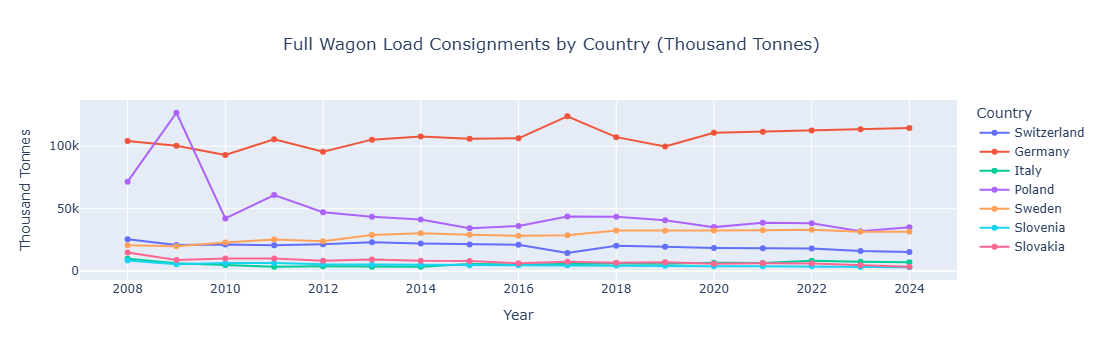

In [21]:
# --- Plot 2: Full Wagon Load ---
fig2 = px.line(
    df_plot,
    x='Year',
    y='Full_Wagon',
    color='Country_Name',
    markers=True,
    title='Full Wagon Load Consignments by Country (Thousand Tonnes)',
    labels={'Full_Wagon': 'Thousand Tonnes', 'Country_Name': 'Country'}
)
fig2.update_layout(title_x=0.5, legend_title_text='Country', hovermode='x unified')
fig2.show()

In the full wagon load consignments, Germany sees an overall increasing trend, barring the decline from 2017-2019 and again increasing since then. Switzerland, Slovakia, Slovenia and Italy have seen relatively lower levels of full wagon load consignments, which were decreasing. Poland has seen a drastic rise and fall in full wagon load consignments since 2010, which could be treated as an outlier considering the data trend thereafter. It continued to decrease further and brief periods of increase from 2016 till 2019. As from the previous graph, it becomes evident that Poland looks to shift to full train consignments instead to meet its demands and requirements.\
Sweden shows a modest rise in the use of full wagon loads , increasing from 23904 in 2012 to 31499 thousand tonnes in 2024, in full wagon load, marking an increase of 31.77 % in 12 years.

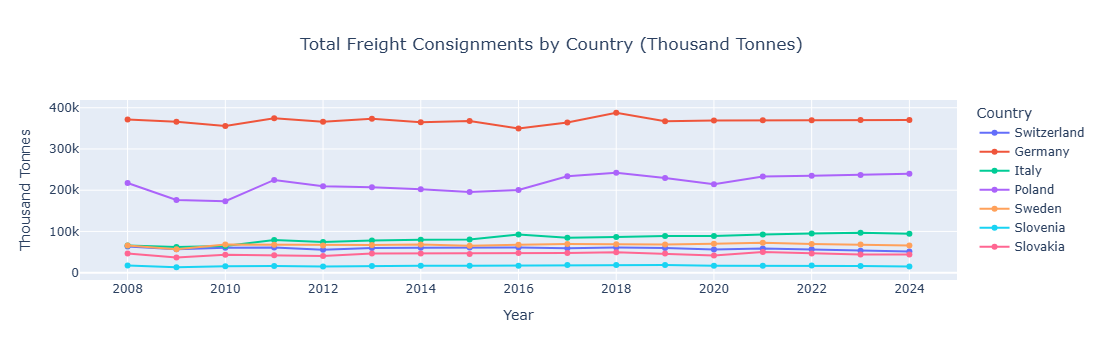

In [22]:
# --- Plot 3: Total Consignments ---
fig3 = px.line(
    df_plot,
    x='Year',
    y='Total',
    color='Country_Name',
    markers=True,
    title='Total Freight Consignments by Country (Thousand Tonnes)',
    labels={'Total': 'Thousand Tonnes', 'Country_Name': 'Country'}
)
fig3.update_layout(title_x=0.5, legend_title_text='Country', hovermode='x unified')
fig3.show()

Through these graphs, we see that there is a growing demand for full train loads as compared to full wagon loads for industry and large-requirement centric countries such as Germany and Italy, as both display an increasing trend.\
Sweden, Slovenia and Slovakia have seen relatively stable freight volume trends, with some variations occurring in Sweden with respect to the Full wagon load consignment type (increasing trend).\
We also observe that the major share of freight consignments is dominated by Germany, then Poland,Italy and thereafter the remaining European countries. 


## Chi-Square Test and Conclusions

The chi-square test shows a statistic of 495,479 with 6 degrees of freedom and a p-value of 0.0. This indicates a significant association between country and the share of full train loads versus full wagon loads. Italy uses full train loads for 92% of its rail freight, while Sweden uses them for 58%. Other countries fall in between. Conclusion: the distribution of consignment types varies significantly across countries.

In [28]:
import pandas as pd
from scipy.stats import chi2_contingency

# Load your dataset (if not already loaded)
df = pd.read_csv("df_merged_filled.csv")

# --- Prepare the data for chi-square test ---
# Aggregate the total consignment types per country
contingency_table = df.groupby('geo')[[
    'Consignment_full_train_load_THS_T',
    'Consignment_full_wagon_load_THS_T'
]].sum()

# Optional: rename columns for readability
contingency_table.columns = ['Full Train Load', 'Full Wagon Load']

# Perform the Chi-square test of independence
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# --- Print the results ---
print("Chi-square Statistic:", chi2)
print("Degrees of Freedom:", dof)
print("P-value:", p_value)
print("\nExpected Frequencies:\n", pd.DataFrame(expected, 
      index=contingency_table.index, 
      columns=contingency_table.columns))

# --- Interpretation ---
alpha = 0.05  # significance level
if p_value < alpha:
    print("\n Reject H0: There IS a significant relationship between country and consignment type distribution.")
else:
    print("\n Fail to Reject H0: There is NO significant relationship between country and consignment type distribution.")


Chi-square Statistic: 495479.5004305262
Degrees of Freedom: 6
P-value: 0.0

Expected Frequencies:
      Full Train Load  Full Wagon Load
geo                                  
CH      7.322487e+05     2.622373e+05
DE      4.608381e+06     1.650381e+06
IT      9.900742e+05     3.545714e+05
PL      2.672675e+06     9.571544e+05
SE      8.424874e+05     3.017167e+05
SI      2.061937e+05     7.384333e+04
SK      4.815584e+05     1.724586e+05

 Reject H0: There IS a significant relationship between country and consignment type distribution.


The chi-square test shows a statistic of 495,479 with 6 degrees of freedom and a p-value of 0.0. This indicates a significant association between country and the share of full train loads versus full wagon loads. Italy uses full train loads for 92% of its rail freight, while Sweden uses them for 58%. Other countries fall in between. Conclusion: the distribution of consignment types varies significantly across countries.